# Import Libraries

In [10]:
import pandas as pd
import pyreadstat
pd.options.display.max_columns = 500
pd.options.display.max_rows = 500
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, precision_score, recall_score, precision_recall_curve, average_precision_score, roc_curve, roc_auc_score
from sklearn.manifold import TSNE
from xgboost import XGBClassifier
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import os
import shap
import joblib

# Loading Data

In [11]:
columns_to_keep = [
    "_AGE80", "SEXVAR", "GENHLTH", "PHYSHLTH", "MENTHLTH", "POORHLTH",
    "PRIMINSR", "MEDCOST1", "CHECKUP1", "EXERANY2", "SLEPTIM1", "LASTDEN4",
    "CVDINFR4", "CVDCRHD4", "CVDSTRK3", "ASTHMA3", "CHCSCNC1", "CHCOCNC1",
    "CHCCOPD3", "ADDEPEV3", "CHCKDNY2", "HAVARTH4", "DIABETE4",
    "MARITAL", "EDUCA", "RENTHOM1", "VETERAN3", "EMPLOY1", "CHILDREN",
    "INCOME3", "WEIGHT2", "HEIGHT3", "DEAF", "BLIND", "DECIDE", "SMOKDAY2", "USENOW3", "ECIGNOW2", "AVEDRNK3", "COVIDPOS", "CIMEMLOS", "CAREGIV1",
    "ACEDEPRS", "ACEDIVRC", "ACEADSAF",
    "SDHISOLT","SOMALE", "SOFEMALE", "RRCOGNT2", "RRCLASS3"
]

folder_path = "../Data"
version_files = ["LLCP22V1.XPT", "LLCP22V2.XPT", "LLCP22V3.XPT"]

df_list = []

for file in version_files:
    file_path = os.path.join(folder_path, file)
    
    if os.path.exists(file_path):
        print(f"Reading {file} explicitly as XPORT format...")
        try:
            df_ver = pd.read_sas(file_path, format="xport", encoding="latin1")
            
            # CRITICAL FIX: Force uppercase AND strip invisible trailing white spaces from SAS layout
            df_ver.columns = df_ver.columns.str.upper().str.strip()
            
            # Find the match now that spaces are removed
            valid_cols_to_read = [col for col in columns_to_keep if col.upper() in df_ver.columns]
            
            # Filter safely
            df_filtered = df_ver[valid_cols_to_read].copy()
            df_list.append(df_filtered)
            print(f"-> Successfully processed {file} ({len(df_filtered)} rows).")
            
        except Exception as e:
            print(f"-> Failed to read {file}. Error: {e}")
    else:
        print(f"Skipping {file}: File path does not exist.")

if df_list:
    df_2022 = pd.concat(df_list, axis=0, ignore_index=True)
    print("\n--- Success! Dataset Generated ---")
    print(f"Total Rows Combined: {len(df_2022)}")
    
    # Safely look for the cleaned SDHISOLT variable
    if 'SDHISOLT' in df_2022.columns:
        print(f"Total Valid Values for SDHISOLT: {df_2022['SDHISOLT'].notna().sum()}")
    else:
        print("Warning: SDHISOLT was not found in any of the processed files.")
        
    print(df_2022.head())
else:
    print("Execution ended: No data could be processed.")

Reading LLCP22V1.XPT explicitly as XPORT format...
-> Successfully processed LLCP22V1.XPT (63923 rows).
Reading LLCP22V2.XPT explicitly as XPORT format...
-> Successfully processed LLCP22V2.XPT (51545 rows).
Reading LLCP22V3.XPT explicitly as XPORT format...
-> Successfully processed LLCP22V3.XPT (20167 rows).

--- Success! Dataset Generated ---
Total Rows Combined: 135635
Total Valid Values for SDHISOLT: 80730
   _AGE80  SEXVAR  GENHLTH  PHYSHLTH  MENTHLTH  POORHLTH  PRIMINSR  MEDCOST1  \
0    73.0     1.0      3.0      88.0      88.0       NaN       3.0       2.0   
1    53.0     2.0      1.0       3.0      88.0      88.0       1.0       2.0   
2    77.0     1.0      3.0      88.0      88.0       NaN       3.0       2.0   
3    68.0     2.0      5.0      15.0      14.0       3.0      10.0       2.0   
4    80.0     2.0      2.0      15.0      88.0      88.0       3.0       2.0   

   CHECKUP1  EXERANY2  SLEPTIM1  LASTDEN4  CVDINFR4  CVDCRHD4  CVDSTRK3  \
0       1.0       1.0       8

# Data Cleaning

In [12]:
zero_code_cols = ["PHYSHLTH", "POORHLTH", "CHILDREN", "AVEDRNK3"]
df_2022[zero_code_cols] = df_2022[zero_code_cols].replace(88, 0)

In [13]:
single_digit_cols = ["GENHLTH", "MEDCOST1", "CHECKUP1", "EXERANY2", "LASTDEN4", "CVDINFR4", "CVDCRHD4", "CVDSTRK3", 
                     "ASTHMA3", "CHCSCNC1", "CHCOCNC1", "CHCCOPD3", "ADDEPEV3", "CHCKDNY2", "HAVARTH4", "DIABETE4",
                     "MARITAL", "EDUCA", "RENTHOM1", "VETERAN3", "EMPLOY1", "DEAF", "BLIND", "DECIDE",
                     "SMOKDAY2", "USENOW3", "ECIGNOW2", "COVIDPOS", "CIMEMLOS", "CAREGIV1", "ACEDEPRS", "ACEDIVRC",
                     "ACEADSAF", "SDHISOLT", "SOMALE", "SOFEMALE", "RRCOGNT2"]
df_2022[single_digit_cols] = df_2022[single_digit_cols].replace([7, 9], np.nan)

In [ ]:
double_digit_cols = ["PHYSHLTH", "MENTHLTH", "POORHLTH", "PRIMINSR", "SLEPTIM1", "CHILDREN", "INCOME3", "AVEDRNK3", "RRCLASS3"]
df_2022[double_digit_cols] = df_2022[double_digit_cols].replace([77, 88, 99], np.nan)

In [15]:
quad_digit_cols = ["WEIGHT2", "HEIGHT3"]
df_2022[quad_digit_cols] = df_2022[quad_digit_cols].replace([7777, 9999], np.nan)

df_2022['WEIGHT2'] = df_2022['WEIGHT2'].mask(df_2022['WEIGHT2'].between(9023, 9352), np.nan)
df_2022['HEIGHT3'] = df_2022['HEIGHT3'].mask(df_2022['HEIGHT3'].between(9061, 9998), np.nan)

In [16]:
columns_to_check = ["GENHLTH", "MEDCOST1", "CHECKUP1", "EXERANY2", "LASTDEN4", "CVDINFR4", "CVDCRHD4", "CVDSTRK3", 
                     "ASTHMA3", "CHCSCNC1", "CHCOCNC1", "CHCCOPD3", "ADDEPEV3", "CHCKDNY2", "HAVARTH4", "DIABETE4",
                     "MARITAL", "EDUCA", "RENTHOM1", "VETERAN3", "EMPLOY1", "DEAF", "BLIND", "DECIDE",
                     "SMOKDAY2", "USENOW3", "ECIGNOW2", "COVIDPOS", "CIMEMLOS", "CAREGIV1", "ACEDEPRS", "ACEDIVRC",
                     "ACEADSAF", "SDHISOLT", "SOMALE", "SOFEMALE", "RRCOGNT2", "PHYSHLTH", "MENTHLTH", 
                     "POORHLTH", "PRIMINSR", "SLEPTIM1", "CHILDREN", "INCOME3", "AVEDRNK3", "RRCLASS3", "WEIGHT2", "HEIGHT3"]

print(df_2022[columns_to_check].isna().sum())

GENHLTH        374
MEDCOST1       490
CHECKUP1      1688
EXERANY2       372
LASTDEN4      1746
CVDINFR4      1041
CVDCRHD4      1389
CVDSTRK3       529
ASTHMA3        525
CHCSCNC1       963
CHCOCNC1       755
CHCCOPD3       714
ADDEPEV3       869
CHCKDNY2       611
HAVARTH4       859
DIABETE4       332
MARITAL       1486
EDUCA          731
RENTHOM1      1481
VETERAN3      1817
EMPLOY1      45350
DEAF          6841
BLIND         7123
DECIDE        7966
SMOKDAY2     86064
USENOW3      11106
ECIGNOW2     11678
COVIDPOS     16947
CIMEMLOS    114084
CAREGIV1    109312
ACEDEPRS    111247
ACEDIVRC    111240
ACEADSAF    111514
SDHISOLT     55867
SOMALE       97972
SOFEMALE     93162
RRCOGNT2     74304
PHYSHLTH      3557
MENTHLTH      2948
POORHLTH     59855
PRIMINSR      5610
SLEPTIM1      1679
CHILDREN      5034
INCOME3      29961
AVEDRNK3     71616
RRCLASS3     73111
WEIGHT2      14553
HEIGHT3      11068
dtype: int64


# EDA

In [17]:
df_2022.info()

<class 'pandas.DataFrame'>
RangeIndex: 135635 entries, 0 to 135634
Data columns (total 50 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   _AGE80    135635 non-null  float64
 1   SEXVAR    135635 non-null  float64
 2   GENHLTH   135261 non-null  float64
 3   PHYSHLTH  132078 non-null  float64
 4   MENTHLTH  132687 non-null  float64
 5   POORHLTH  75780 non-null   float64
 6   PRIMINSR  130025 non-null  float64
 7   MEDCOST1  135145 non-null  float64
 8   CHECKUP1  133947 non-null  float64
 9   EXERANY2  135263 non-null  float64
 10  SLEPTIM1  133956 non-null  float64
 11  LASTDEN4  133889 non-null  float64
 12  CVDINFR4  134594 non-null  float64
 13  CVDCRHD4  134246 non-null  float64
 14  CVDSTRK3  135106 non-null  float64
 15  ASTHMA3   135110 non-null  float64
 16  CHCSCNC1  134672 non-null  float64
 17  CHCOCNC1  134880 non-null  float64
 18  CHCCOPD3  134921 non-null  float64
 19  ADDEPEV3  134766 non-null  float64
 20  CHCKDNY2  13502

Dropping (sparsity, <15% non-null): CDHELP, CDSOCIAL, CRGVLNG1, CRGVHRS1, HADSEX, CNCRTYP2, RCSRLTN2, RCSGEND1, FIREARM5

Dropping (structural/content reason, not sparsity): PREGNANT, HADHYST2

Keeping everything else and substituting sentinel codes with NaN

Noting that LSATISFY, EMTSUPRT, and SDHSTRE1 all are in the same question section (Social Determinants and Health Equity) as target variable.

Going to drop due to overlap with target variable. 

Replacing all dont know/refused answers across columns to NaN. 

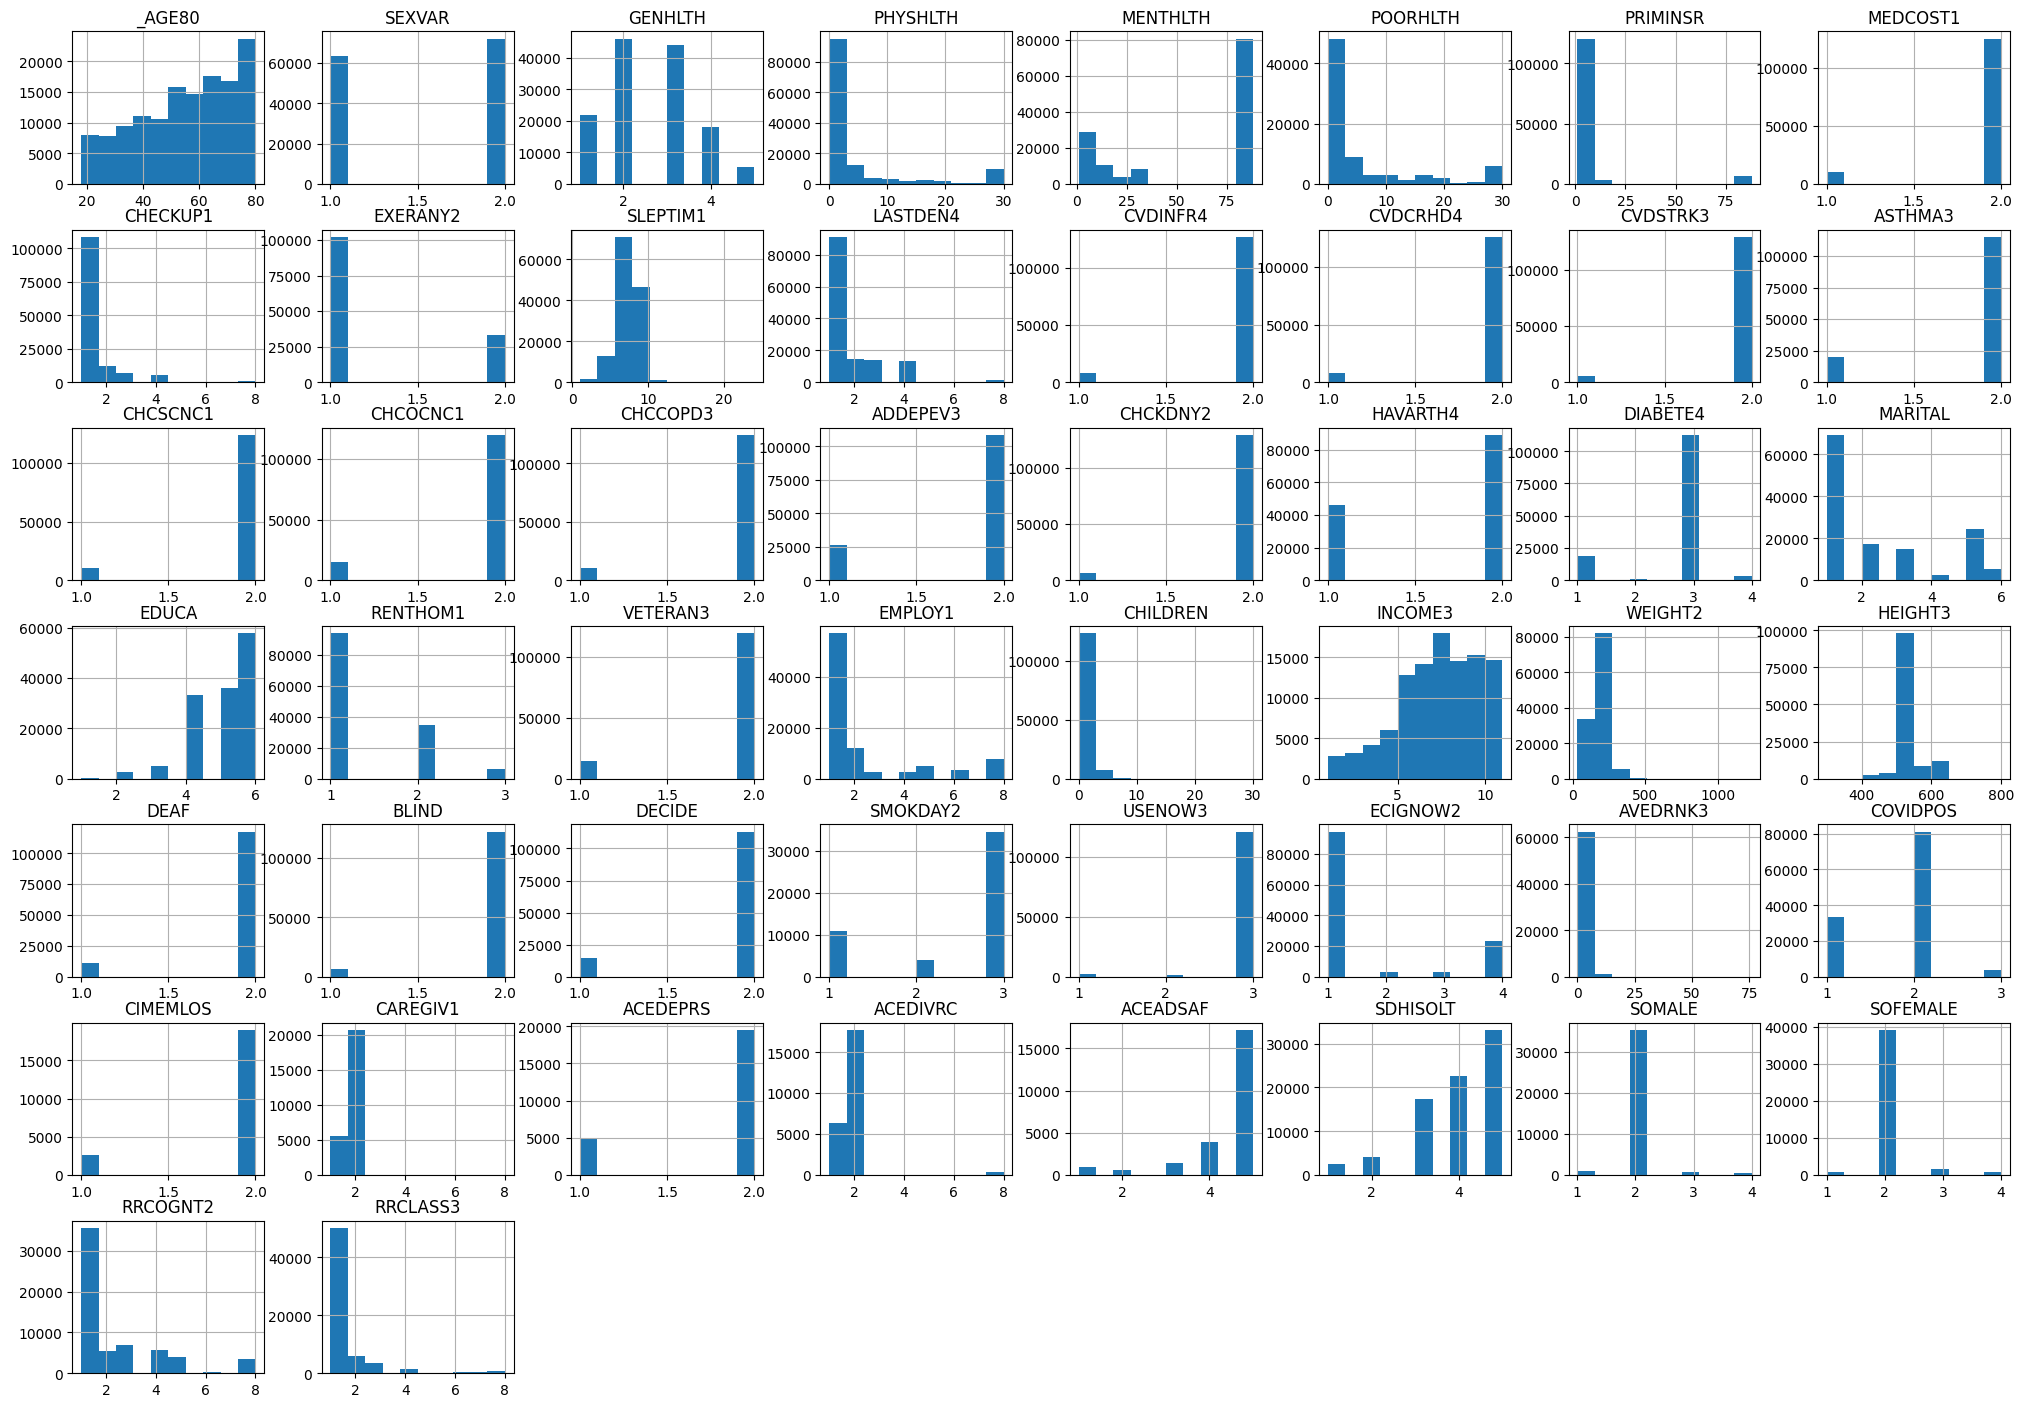

In [18]:
df_2022.hist(layout=(8, 8),   
    figsize=(25, 20), 
)
plt.show()

In [19]:
corr_matrix = df_2022.corr()

# Keep only the upper triangle, so each pair appears once
mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
corr_pairs = corr_matrix.where(mask).stack()

threshold = 0.40
strong_pairs = corr_pairs[abs(corr_pairs) >= threshold].sort_values(key=abs, ascending=False)
print(strong_pairs)

PHYSHLTH  POORHLTH    0.537751
GENHLTH   PHYSHLTH    0.489380
SEXVAR    HEIGHT3    -0.488400
CVDINFR4  CVDCRHD4    0.441514
EMPLOY1   INCOME3    -0.439803
EDUCA     INCOME3     0.430951
MARITAL   RENTHOM1    0.413190
DECIDE    CIMEMLOS    0.409536
dtype: float64


In [20]:
df_sampled = df_2022.sample(frac=0.2, random_state=1)

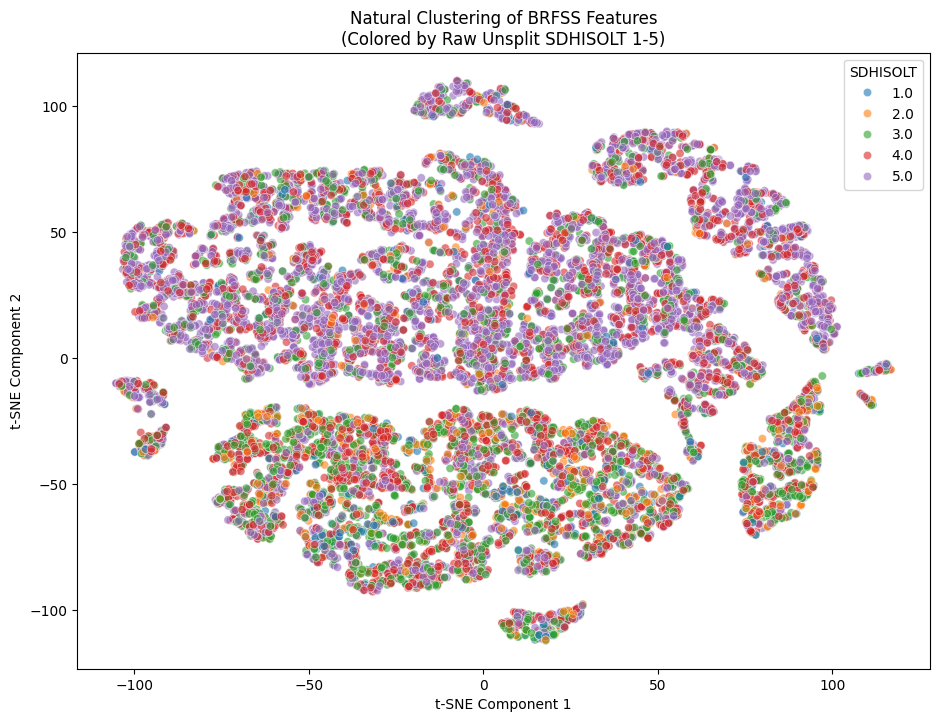

In [21]:
# 1. Create a safe copy of X_test and impute NaNs JUST for t-SNE
# We use the column medians so it doesn't distort the geometric distances
features_only = df_sampled.drop(columns=['SDHISOLT'])
df_2022_imputed = features_only.fillna(features_only.median())

# 2. Fit t-SNE onto your clean, imputed feature columns
tsne_raw = TSNE(n_components=2, perplexity=30, random_state=1, n_jobs=1)
raw_tsne_results = tsne_raw.fit_transform(df_2022_imputed)

# 3. Pull the raw 1-5 survey scale for the matching records
raw_target = df_sampled.loc[df_2022_imputed.index, 'SDHISOLT']

# 4. Generate the map
plt.figure(figsize=(11, 8))
sns.scatterplot(
    x=raw_tsne_results[:, 0], 
    y=raw_tsne_results[:, 1], 
    hue=raw_target.astype('category'),
    palette='tab10',  # Renders 1 through 5 as a clean shifting color spectrum
    alpha=0.6,
    legend='full'
)

plt.title('Natural Clustering of BRFSS Features\n(Colored by Raw Unsplit SDHISOLT 1-5)')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.show()

Values 1 to 3 seem to clump close together (always to sometimes) as does 4-5 (rarely and never). Therefore, splitting on 3/4 for binary target variable. 

# Prepping and Building Model

In [22]:
df_2022["y_recoded"] = df_2022["SDHISOLT"].replace(
    {1: 1, 2: 1, 3: 1, 4: 0, 5: 0, 7: np.nan, 9: np.nan}
)
df_2022.drop("SDHISOLT", axis=1, inplace=True)

In [23]:
df_for_model = df_2022.dropna(subset=['y_recoded'])

In [24]:
X = df_for_model.drop('y_recoded', axis=1)
y = df_for_model['y_recoded']

In [25]:
print(y.value_counts())

y_recoded
0.0    55802
1.0    23966
Name: count, dtype: int64


In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

One hot encode PRIMINSR, DIABETE4, COVIDPOS, CAREGIV1, ACEDIVRC, RRCLASS3, SOMALE, SOFEMALE, MARITAL, EMPLOY1, RENTHOM1

In [27]:
categorical_cols = ['PRIMINSR', 'DIABETE4', 'COVIDPOS', 'CAREGIV1', 'ACEDIVRC', 'RRCLASS3', 'SOMALE', 'SOFEMALE', 'MARITAL', 'EMPLOY1', 'RENTHOM1']

In [28]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ],
    remainder='passthrough'  # Crucial: This ensures numerical columns aren't dropped!
)

In [ ]:
cv_strategy = StratifiedKFold(
    n_splits=5,          # Divide data into 5 folds (K=5)
    shuffle=True,        # Enables shuffling before splitting
    random_state=1      # Ensures reproducibility
)
# 5 k fold split and randomize fold order

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        objective='binary:logistic', # Defines binary classification
        eval_metric='auc',       # Evaluation metric to prevent warnings
        random_state=1,
        learning_rate=0.1,
        max_depth=4,
        scale_pos_weight=1.5
    ))
])

#Scale pos weight forces the model to prioritize catching the rare class by penalizing it heavily whenever it misses one.

# Note to self: Missing a positive instance is 1.5 times worse than making a false alarm based on scale_pos_weight =1.5. 

#Binary classifier. Logistic cause its 0,1. AUC because focused on class labeling. Other option is logloss, need to study up on. Others are hyperparameters. 

scores = cross_val_score(
    pipeline,            
    X_train,                   
    y_train,                   
    cv=cv_strategy,      
    scoring='precision'    
)
print(f"Precision Scores per fold: {scores}")
print(f"Mean Precision: {scores.mean():.3f} (+/- {scores.std():.3f})")

# Practice run. Used to test hyperparameters and adjust if necessary.

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

# Real run. Computer taking it seriously.

Precision Scores per fold: [0.60133495 0.60233559 0.61153728 0.60036496 0.58816314]
Mean Precision: 0.601 (+/- 0.007)


# Model Evaluation

In [30]:
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.2f}")
print(f"Precision: {precision_score(y_test, y_pred):.2f}")
print(f"Recall: {recall_score(y_test, y_pred):.2f}")

Accuracy: 0.75
ROC-AUC: 0.77
Precision: 0.60
Recall: 0.52


## Baseline Comparison

In [31]:
numeric_cols = [c for c in X_train.columns if c not in categorical_cols]

baseline_preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True), categorical_cols),
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numeric_cols)
    ]
)

baseline_pipeline = Pipeline(steps=[
    ('preprocessor', baseline_preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=1))
])

baseline_pipeline.fit(X_train, y_train)
y_pred_baseline = baseline_pipeline.predict(X_test)
y_proba_baseline = baseline_pipeline.predict_proba(X_test)[:, 1]

print(f"Baseline Accuracy: {accuracy_score(y_test, y_pred_baseline):.2f}")
print(f"Baseline ROC-AUC: {roc_auc_score(y_test, y_proba_baseline):.2f}")
print(f"Baseline Precision: {precision_score(y_test, y_pred_baseline):.2f}")
print(f"Baseline Recall: {recall_score(y_test, y_pred_baseline):.2f}")

Baseline Accuracy: 0.71
Baseline ROC-AUC: 0.76
Baseline Precision: 0.51
Baseline Recall: 0.66


Xgboost did not perform any better than logistic regression. The precision/recall difference between the two reflects mismatched imbalance-correction 
strength (scale_pos_weight=1.5 vs class_weight='balanced'), not a difference in the models themselves. We can tune Xgboost for the desired outcome based on the precision/recall tradeoff without using imputation techniques. 

Had to keep it to 2000 samples due to hardware constraints

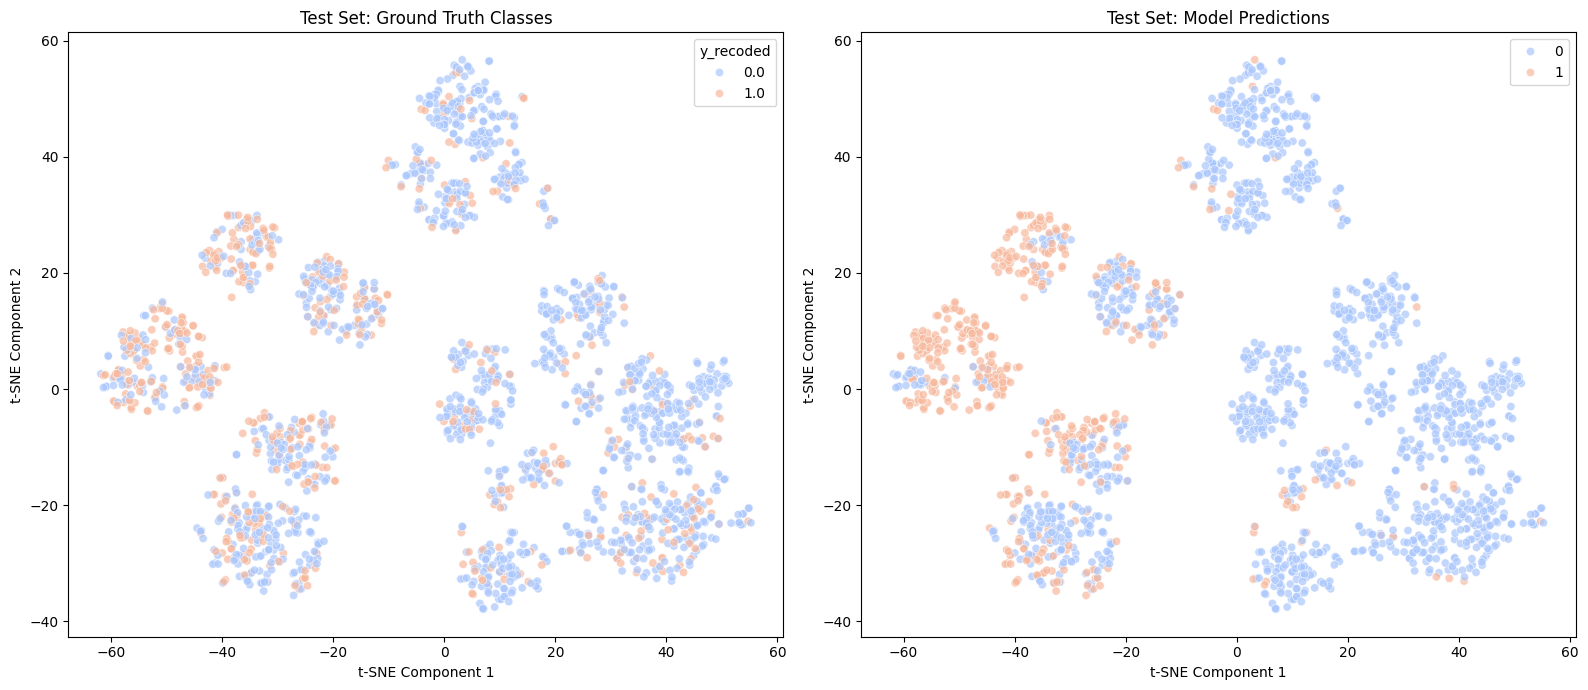

In [32]:
# 1. Extract the classifier from your pipeline step
xgb_model = pipeline.named_steps['classifier']

#Telling t-sne its a classifier. Ie, Go inside the pipeline, find the step I named 'classifier', and let me work with that object directly.

sample_idx, _ = train_test_split(
    X_test.index,
    train_size=2000,
    stratify=y_test,
    random_state=1
)
X_test_sample = X_test.loc[sample_idx]
y_test_sample = y_test.loc[sample_idx]


X_test_sample_transformed = pipeline[:-1].transform(X_test_sample)

# 2. Extract leaf IDs directly using .apply() 
# This bypasses the need for get_booster() and DMatrix entirely
leaf_embeddings = xgb_model.apply(X_test_sample_transformed)

#Running the model and labeling all the leaves at the end. 

# 3. Fit t-SNE on the tree path configurations
tsne = TSNE(n_components=2, perplexity=30, random_state=1, n_jobs=1)
tsne_results = tsne.fit_transform(leaf_embeddings)

# Number of components is number of axes/dimensions (in this case 2D). Perplexity is number of data points, so for each data point, 
#                                                                       look at 30 nearest neighbors to choose where each point is mapped.
y_pred_sample = pipeline.predict(X_test_sample)
# 4. Generate side-by-side plots for visual error analysis
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: Ground Truth
sns.scatterplot(
    ax=axes[0], x=tsne_results[:, 0], y=tsne_results[:, 1], 
    hue=y_test_sample, palette='coolwarm', alpha=0.7
)
axes[0].set_title('Test Set: Ground Truth Classes')
axes[0].set_xlabel('t-SNE Component 1')
axes[0].set_ylabel('t-SNE Component 2')

# Plot 2: Model Predictions
sns.scatterplot(
    ax=axes[1], x=tsne_results[:, 0], y=tsne_results[:, 1], 
    hue=y_pred_sample, palette='coolwarm', alpha=0.7
)
axes[1].set_title('Test Set: Model Predictions')
axes[1].set_xlabel('t-SNE Component 1')
axes[1].set_ylabel('t-SNE Component 2')

plt.tight_layout()
plt.show()

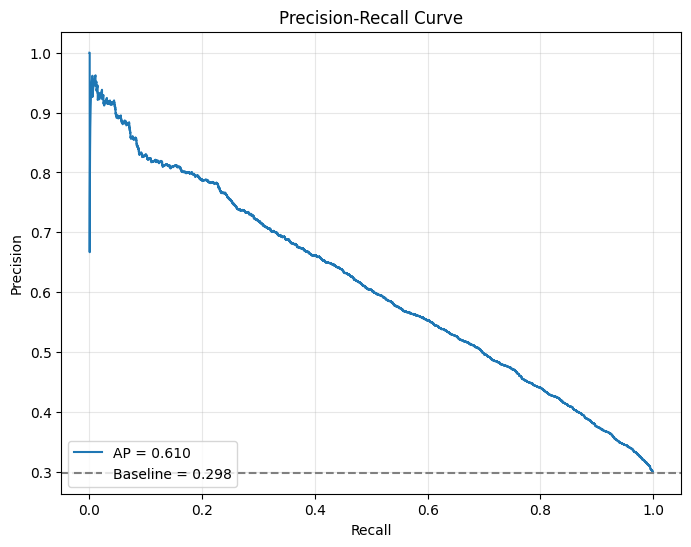

In [33]:
# 1. Get predicted probabilities for the positive class
y_scores = pipeline.predict_proba(X_test)[:, 1]

# 2. Compute precision, recall at every threshold
precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

# 3. Compute average precision (area under the PR curve — a single summary number)
ap_score = average_precision_score(y_test, y_scores)

baseline = y_test.mean()

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'AP = {ap_score:.3f}')
plt.axhline(baseline, linestyle='--', color='gray', label=f'Baseline = {baseline:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.grid(alpha=0.3)
plt.show()

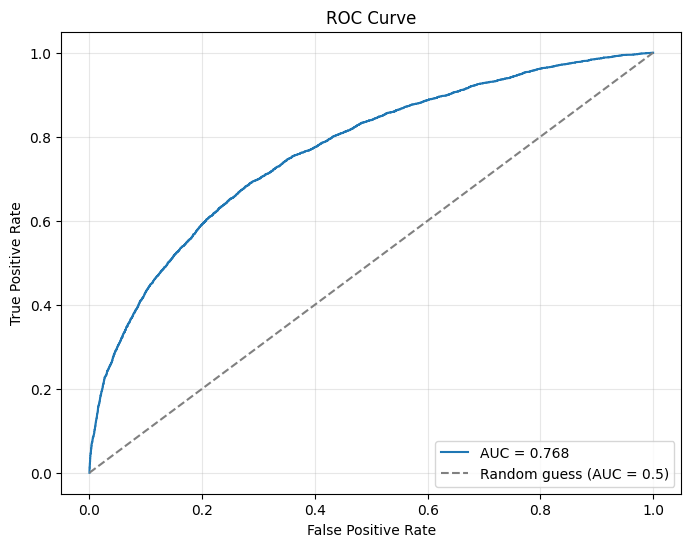

In [34]:
# 1. Get predicted probabilities for the positive class
y_scores = pipeline.predict_proba(X_test)[:, 1]

# 2. Compute false positive rate, true positive rate at every threshold
fpr, tpr, thresholds = roc_curve(y_test, y_scores)

# 3. AUC — you already have this number (0.77), this just recomputes it for the plot
auc = roc_auc_score(y_test, y_scores)

# 4. Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

# SHAP 

100%|===================| 15948/15954 [00:47<00:00]        

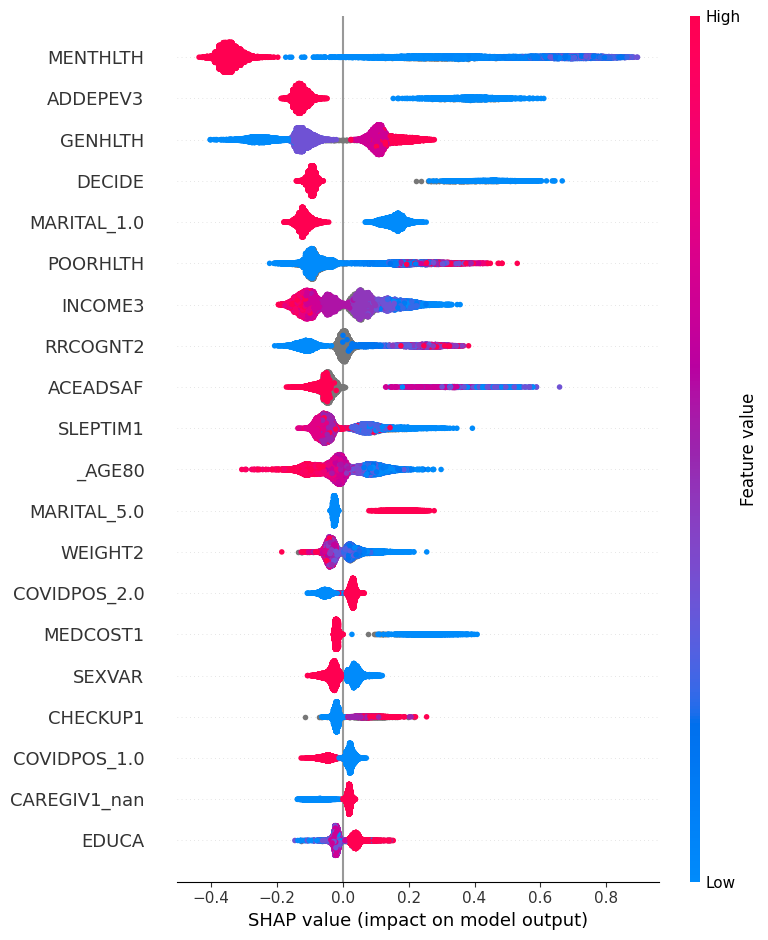

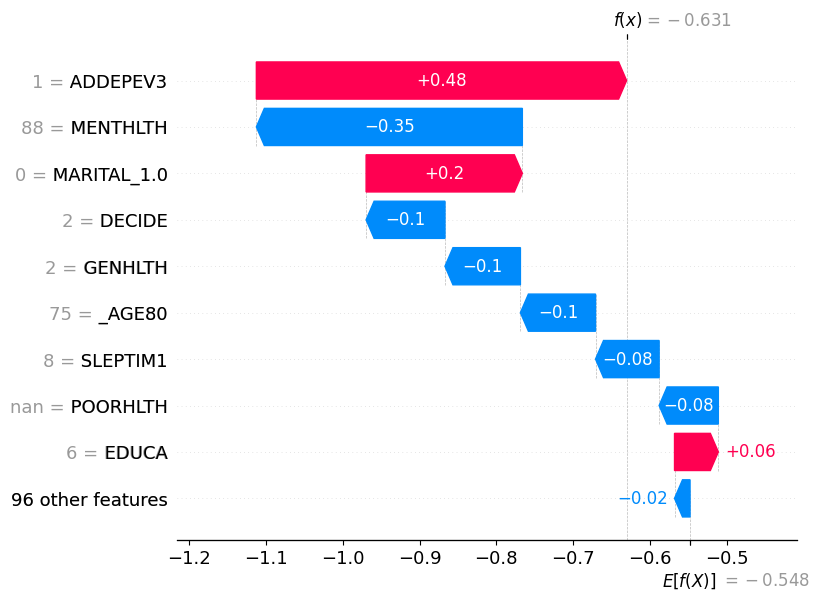

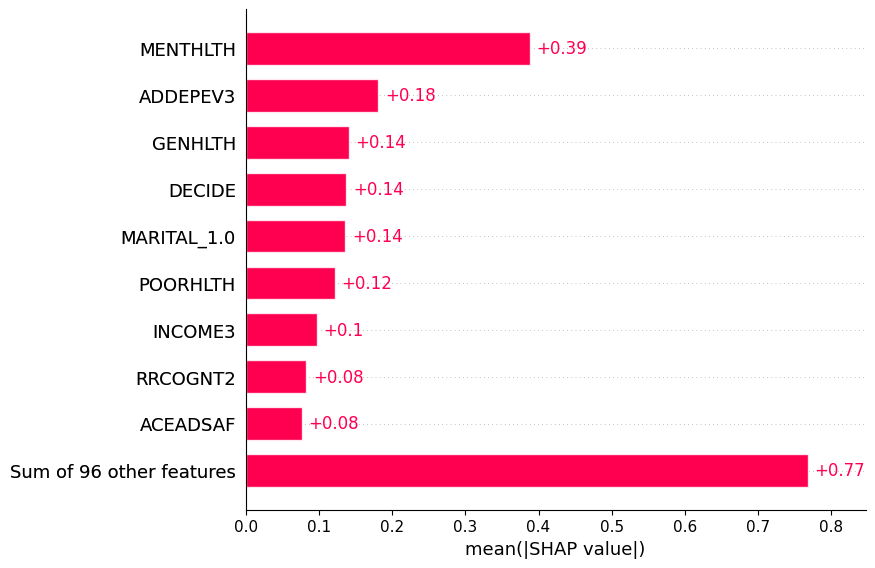

In [35]:
# 1. Transform train/test through the same preprocessing the model was trained on
X_train_transformed = pipeline[:-1].transform(X_train)
X_test_transformed = pipeline[:-1].transform(X_test)

# 2. Recover readable feature names — otherwise every plot will show "x0", "x1", etc. 
#    instead of "MARITAL_2.0", "PRIMINSR_88.0", etc.
feature_names = pipeline[:-1].get_feature_names_out()

feature_names = [name.split('__', 1)[1] for name in feature_names]

# 3. Initialize the SHAP Explainer on the transformed data
explainer = shap.Explainer(xgb_model, X_train_transformed, feature_names=feature_names)
shap_values = explainer(X_test_transformed)

# 4. Visualize the results — same calls as before
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names)
shap.plots.waterfall(shap_values[0])
shap.plots.bar(shap_values)

MENTHLTH: (for how many days during the past 30 days was your mental health not good?)

ADDEPEV3: (Ever told) (you had) a depressive disorder (including depression, major depression, dysthymia, or minor depression).

DECIDE: (Because of a physical, mental, or emotional condition, do you have serious difficulty concentrating, remembering, or making decisions?)

MARITAL
Are you: (marital status)

GENHLTH: (Would you say that in general your health is)

POORHLTH: (During the past 30 days, for about how many days did poor physical or mental health keep you from doing your usual activities, such as self-care, work, or recreation?)

INCOME3
Is your annual household income from all sources?

RRCOGNT2: (How often do you think about your race?)

ACEADSAF: (For how much of your childhood was there an adult in your household who made you feel safe and protected?).

SLEPTIM1: (On average, how many hours of sleep do you get in a 24-hour period?).

_AGE80, older you are the less lonely you are?

SEXVAR: Sex of Respondent

COVIDPOS: (Has a doctor, nurse, or other health professional ever told you that you tested positive for COVID 19).

MEDCOST1: Was there a time in the past 12 months when you needed to see a doctor but could not because you could not afford it?

WEIGHT2: About how much do you weigh without shoes?

AVEDRNK3: (During the past 30 days, on the days when you drank, about how many drinks did you drink on the average?)

CHECKUP1: About how long has it been since you last visited a doctor for a routine checkup?

## SHAP Interpretation

General and poor health I think are measuring the same thing. 

The more you think about your race the lonelier you are, worth looking into. 

A lack of responsible adult, its interesting how it appears to affect both ends.

Higher age makes you less lonely. 

Could be an issue with the sex variable.

Medcost is related to the income part I imagine.

The covid positive variable is worth looking into. 

Unsure about checkup, but mobility or economic issue possibly. 

Higher weight again probably measuring the same thing as general and poor health variables. 

Drinking and education also worth looking at. 

Marriage, the type of arragement seems to be a large factor. 

## SHAPS of individual Variables of Interest

### Marriage Variable

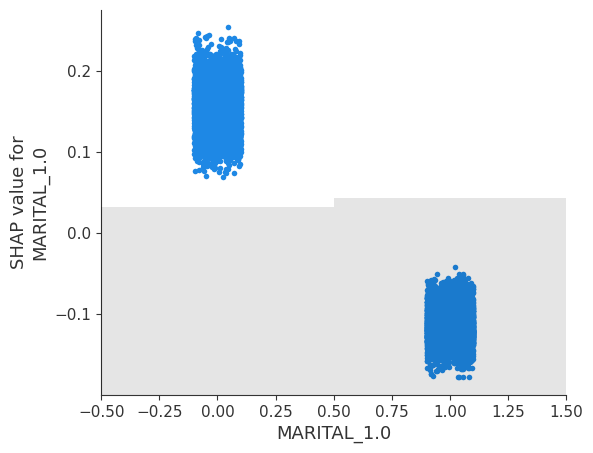

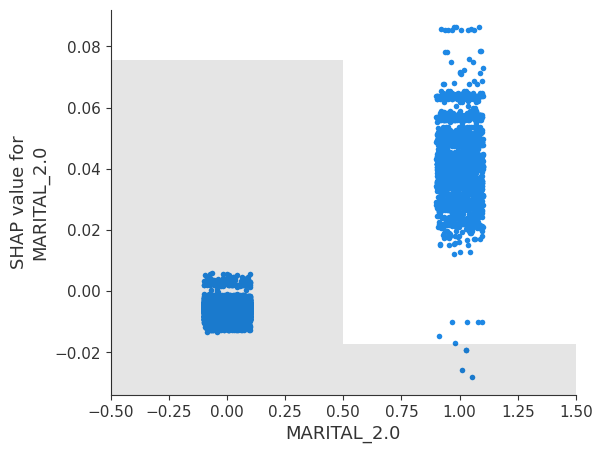

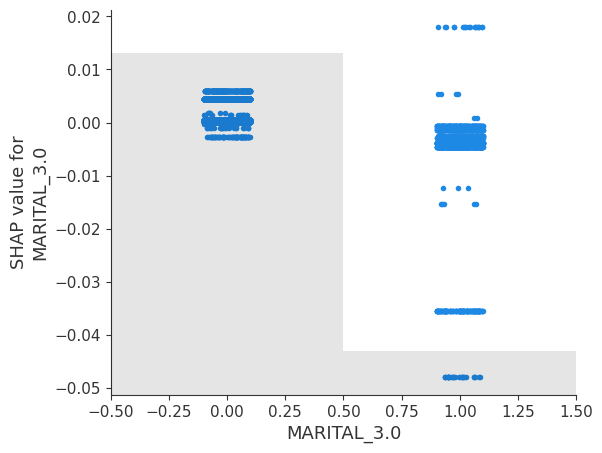

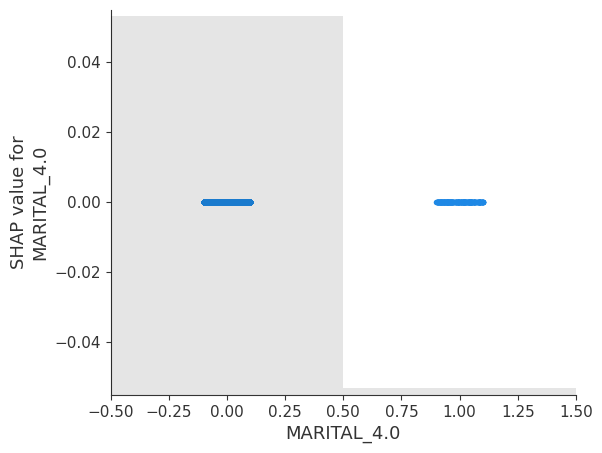

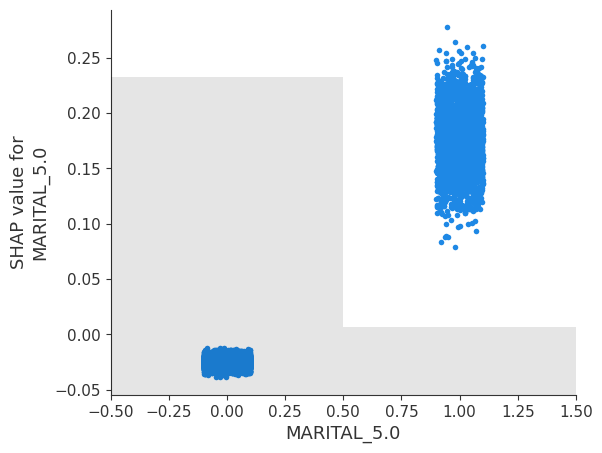

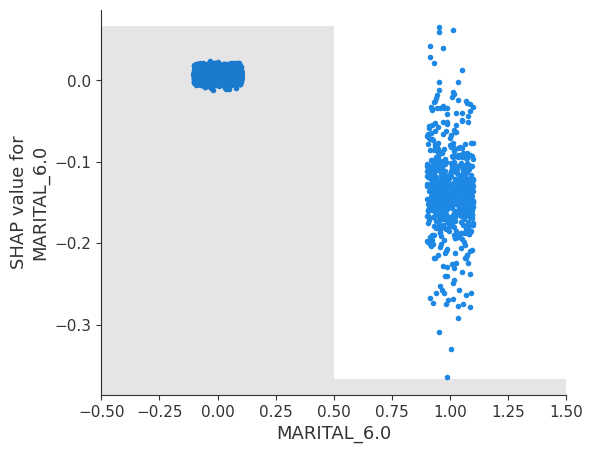

In [36]:
shap.plots.scatter(shap_values[:,"MARITAL_1.0"])
shap.plots.scatter(shap_values[:,"MARITAL_2.0"])
shap.plots.scatter(shap_values[:,"MARITAL_3.0"])
shap.plots.scatter(shap_values[:,"MARITAL_4.0"])
shap.plots.scatter(shap_values[:,"MARITAL_5.0"])
shap.plots.scatter(shap_values[:,"MARITAL_6.0"])

Being married makes you less lonely, divorced it does not help but the impact seems minor by comparison. Widowed and separated seem to have no impact. Never married seems to make you the loneliest. Being part of an unorthodox arrangement seems to have the same impact as being married or widowed.

### Think about race variable

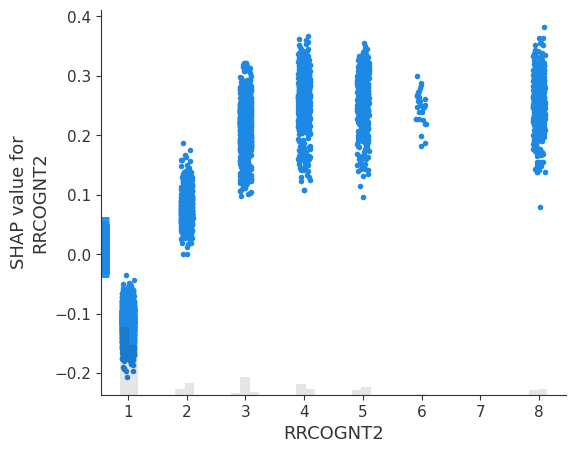

In [37]:
shap.plots.scatter(shap_values[:,"RRCOGNT2"])

So if you think about it in almost any capacity, it makes you higher likelihood of feeling lonely. Although the rate of this seems consistent across the frequency of thinking about it. If you don't think about it, your less likely to be lonely. 

### Had an adult in household that made you feel safe variable

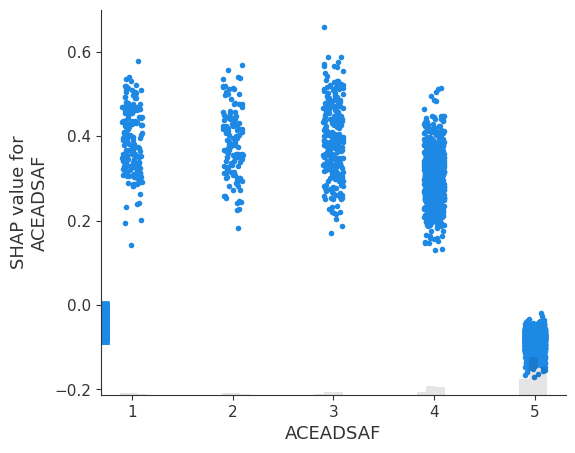

In [38]:
shap.plots.scatter(shap_values[:,"ACEADSAF"])

Okay so if you had an adult you felt safe with all the time in your household as a child, the effect on loneliness might be null or slightly preventative. Any other answer, higher likelihood of loneliness. Although, similar to race, surprisingly the less the feeling is, it does not seem to affect rate of feeling lonely.

### Age Variable

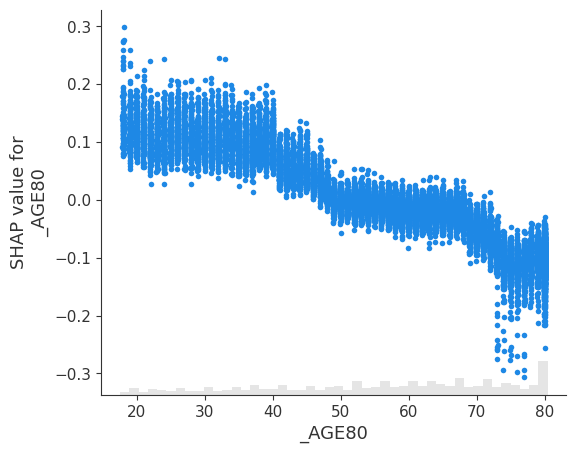

In [39]:
shap.plots.scatter(shap_values[:,"_AGE80"])

Seems there is a steady decline in loneliness as you get older. 

### Sex Variable

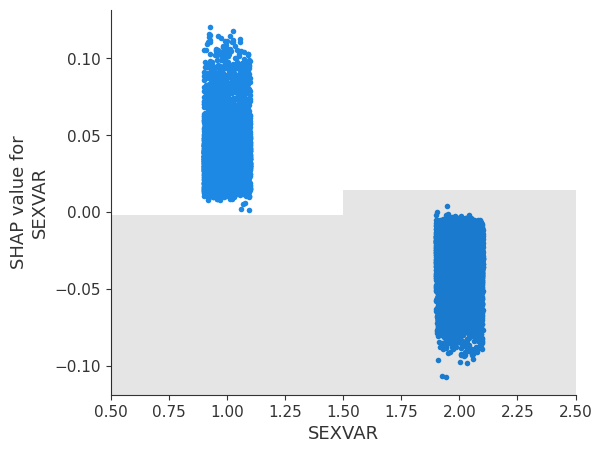

In [40]:
shap.plots.scatter(shap_values[:,"SEXVAR"])

Clear contrast, if your a male, your more likely to be lonely. If your a female, your less likely to be lonely. 

### Covid Positive Variable

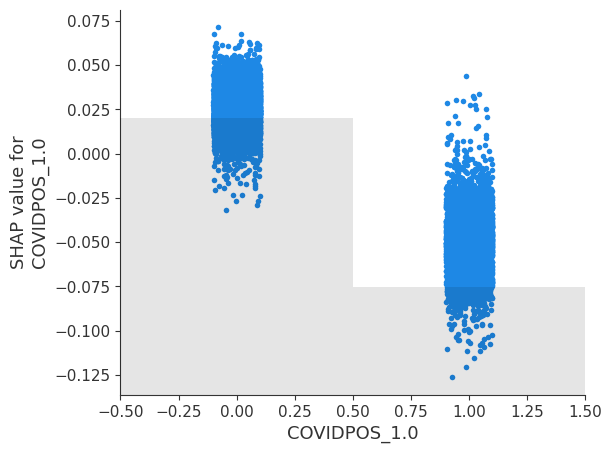

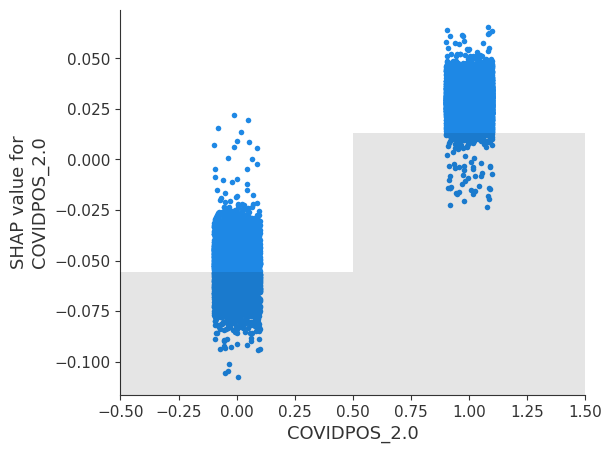

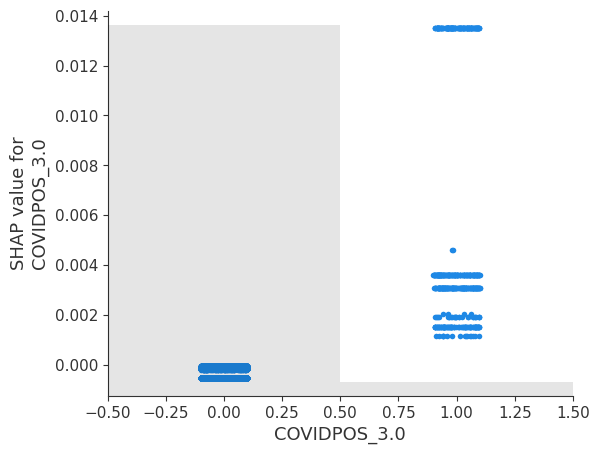

In [41]:
shap.plots.scatter(shap_values[:,"COVIDPOS_1.0"])
shap.plots.scatter(shap_values[:,"COVIDPOS_2.0"])
shap.plots.scatter(shap_values[:,"COVIDPOS_3.0"])

Testing positive for Covid made you less likely to be lonely, and not testing positive made you more likely to be lonely? Could be a social activity proxy (more social you are the more likely you were to get covid)

### Drinking Variable

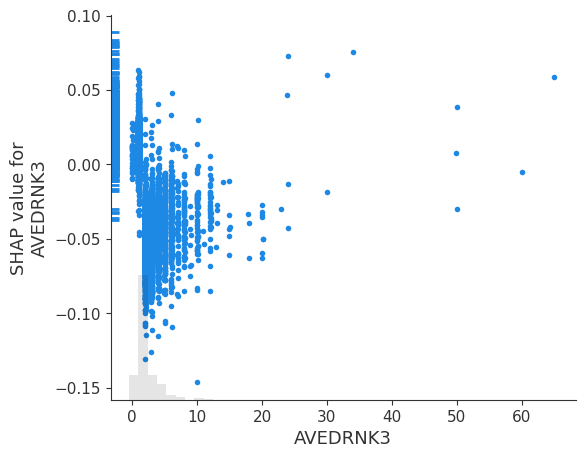

In [42]:
shap.plots.scatter(shap_values[:,"AVEDRNK3"])

Not drinking seems to make you more likey to be lonely. Could be an effect from the NaNs. If you drink less likely to be lonely. It could be a social thing, ie it looks weird not to drink and be at a bar when your not drinking. 

### Education Variable

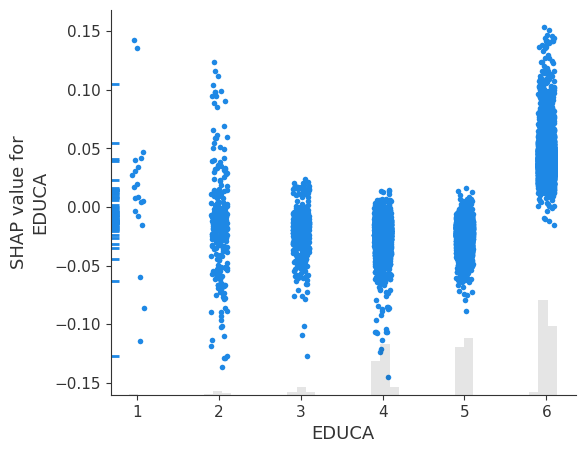

In [43]:
shap.plots.scatter(shap_values[:,"EDUCA"])

Its odd that being a college graduate makes you more likely to be lonely. Might be related to other things like age. 

# Pickling

In [44]:
joblib.dump(pipeline, '../Models/BRFSS_Loneliness_Pipeline.pkl')

['../Models/BRFSS_Loneliness_Pipeline.pkl']

In [45]:
loaded_pipeline = joblib.load('../Models/BRFSS_Loneliness_Pipeline.pkl')

original_preds = pipeline.predict(X_test)
loaded_preds = loaded_pipeline.predict(X_test)
print("Predictions match:", np.array_equal(original_preds, loaded_preds))

Predictions match: True


In [46]:
pip freeze > requirements.txt

Note: you may need to restart the kernel to use updated packages.
